In [ ]:
ls "/"

bin@                        lib32@                    root/
boot/                       lib64@                    run/
content/                    libx32@                   sbin@
cuda-keyring_1.1-1_all.deb  media/                    srv/
datalab/                    mnt/                      sys/
dev/                        NGC-DL-CONTAINER-LICENSE  tmp/
etc/                        opt/                      tools/
home/                       proc/                     usr/
kaggle/                     python-apt/               var/
lib@                        python-apt.tar.xz*


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/abc/Cleaned_Dataset.csv")

df = pd.read_csv(file_path)

df.head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df

,artists,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,hit
0,Gen Hoshino,Comedy,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1
1,Ben Woodward,Ghost - Acoustic,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,0
2,Ingrid Michaelson;ZAYN,To Begin Again,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,0
3,Kina Grannis,Can't Help Falling In Love,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1
4,Chord Overstreet,Hold On,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113994,Rainy Lullaby,Sleep My Little Boy,384999,0,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,0
113995,Rainy Lullaby,Water Into Light,385000,0,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,0
113996,Cesária Evora,Miss Perfumado,271466,0,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,0
113997,Michael W. Smith,Friends,283893,0,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,0


In [ ]:
df.columns

Index(['artists', 'track_name', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre', 'hit'],
      dtype='object')

In [ ]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

df = df.drop_duplicates(subset=[track_name])

In [ ]:
def standard_scaler(data):

    scaled_data = data.copy()

    for col in data.columns:

        mean = data[col].mean()
        std = data[col].std()

        scaled_data[col] = (data[col] - mean) / std

    return scaled_data

In [ ]:
scaled_features = standard_scaler(df[features])

## euclidean distance

In [ ]:
def euclidean_distance(a, b):

    total = 0

    for i in range(len(a)):

        total += (a[i] - b[i]) ** 2

    return total ** 0.5

In [ ]:
k = 5

data = scaled_features.values

centroids = data[:k]

for iteration in range(100):

    # ---------------- ASSIGN STEP ----------------
    clusters = []

    for point in data:

        distances = []

        for centroid in centroids:

            dist = euclidean_distance(
                point,
                centroid
            )

            distances.append(dist)

        cluster = distances.index(min(distances))
        clusters.append(cluster)

    clusters = np.array(clusters)

    new_centroids = []

    for j in range(k):

        cluster_points = data[clusters == j]

        if len(cluster_points) == 0:
            new_centroids.append(centroids[j])
        else:
            new_centroids.append(cluster_points.mean(axis=0))

    new_centroids = np.array(new_centroids)

    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_size = 10000

indices = np.random.choice(
    len(scaled_features),
    sample_size,
    replace=False
)

score = silhouette_score(
    scaled_features.iloc[indices],
    clusters[indices]
)

print("Silhouette Score:", score)

Silhouette Score: 0.17978955712245748


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=9)

reduced = pca.fit_transform(scaled_features)

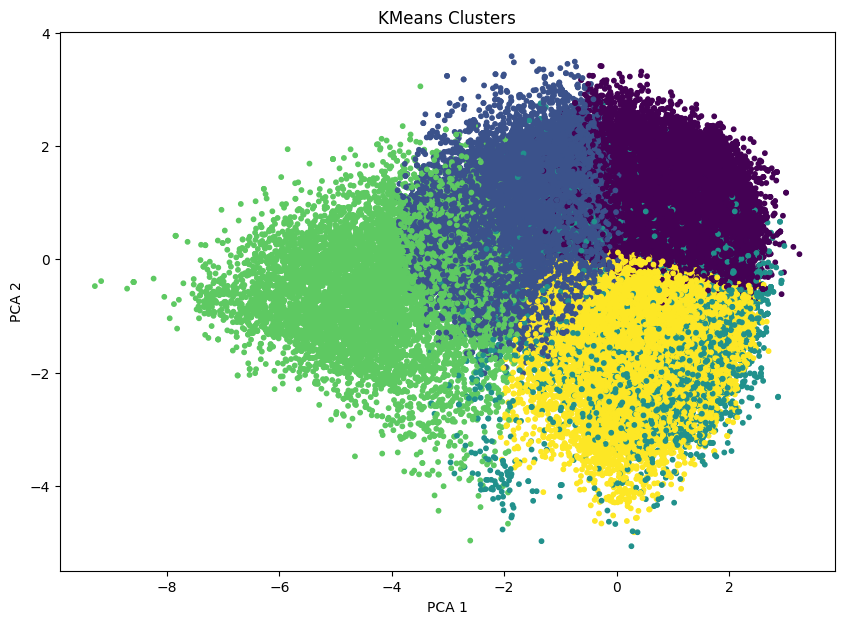

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters,
    s=10
)

plt.title("KMeans Clusters")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [ ]:
df['cluster'] = clusters
for i in range(5):

    print(f"\n===== Cluster {i} =====")

    print(
        df[df['cluster'] == i][
            ['track_name', 'artists', 'track_genre']
        ].head(10)
    )


===== Cluster 0 =====
                track_name                    artists track_genre
0                   Comedy                Gen Hoshino    acoustic
5     Days I Will Remember               Tyrone Wells    acoustic
8                    Lucky  Jason Mraz;Colbie Caillat    acoustic
14         Hold On - Remix   Chord Overstreet;Deepend    acoustic
18                   Lucky  Jason Mraz;Colbie Caillat    acoustic
24                Unlonely                 Jason Mraz    acoustic
27          If It Kills Me                 Jason Mraz    acoustic
42  You and Me on the Rock      Brandi Carlile;Lucius    acoustic
43  You and Me on the Rock      Brandi Carlile;Lucius    acoustic
45  You and Me on the Rock      Brandi Carlile;Lucius    acoustic

===== Cluster 1 =====
                    track_name                               artists  \
1             Ghost - Acoustic                          Ben Woodward   
2               To Begin Again                Ingrid Michaelson;ZAYN   
3   Can't He

In [ ]:
## agglomerative

In [ ]:
import numpy as np

class ManualAgglomerative:

    def __init__(self, n_clusters=5):
        self.n_clusters = n_clusters

    # Euclidean distance
    def euclidean_distance(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    # Distance between two clusters
    def cluster_distance(self, cluster1, cluster2, data):

        distances = []

        for i in cluster1:
            for j in cluster2:

                dist = self.euclidean_distance(
                    data[i],
                    data[j]
                )

                distances.append(dist)

        return np.min(distances)   # single linkage

    def fit(self, data):

        data = np.array(data)

        n_samples = len(data)

        # Initially every point is its own cluster
        clusters = [[i] for i in range(n_samples)]

        # Keep merging until desired clusters remain
        while len(clusters) > self.n_clusters:

            min_dist = float('inf')

            cluster_a = None
            cluster_b = None

            # Find closest clusters
            for i in range(len(clusters)):

                for j in range(i + 1, len(clusters)):

                    dist = self.cluster_distance(
                        clusters[i],
                        clusters[j],
                        data
                    )

                    if dist < min_dist:

                        min_dist = dist
                        cluster_a = i
                        cluster_b = j

            # Merge clusters
            clusters[cluster_a] = (
                clusters[cluster_a] +
                clusters[cluster_b]
            )

            del clusters[cluster_b]

        # Create labels
        labels = np.zeros(n_samples)

        for cluster_id, cluster in enumerate(clusters):

            for sample_index in cluster:

                labels[sample_index] = cluster_id

        self.labels_ = labels.astype(int)

        return self

In [ ]:
# STEP 1
sample_data = scaled_features.sample(
    200,
    random_state=42
)

# STEP 2
agglo = ManualAgglomerative(
    n_clusters=5
)

# STEP 3
agglo.fit(sample_data)

# STEP 4
labels = agglo.labels_

print(labels)

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 4 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

labels_agglo = agglo.fit_predict(scaled_features)

NameError: name 'scaled_features' is not defined

## dbscan


apply hybrid and density based clustering on it using sklearn

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# New section

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/abc/Cleaned_Dataset.csv")

In [ ]:
X = df.select_dtypes(include=['int64', 'float64'])

# track_genre target hai to clustering me mat use karo
if 'hit' in X.columns:
    X = X.drop('hit', axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
dbscan = DBSCAN(eps=2.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts())

NameError: name 'DBSCAN' is not defined

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['DBSCAN_Cluster'],
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

KeyError: 'DBSCAN_Cluster'

<Figure size 800x600 with 0 Axes>

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df['DBSCAN_Cluster']
)

print(score)

NameError: name 'X_scaled' is not defined

# New Section

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
df_1000 = df.head(1000)

print(df_1000.shape)

NameError: name 'df' is not defined